# CNMFe Tutorial — realistic miniscope movie

Same structure as `tutorial2.ipynb`, but the synthetic dataset is generated by `tests/miniscope_simulator.py::make_miniscope_movie` instead of the clean fixture in `conftest.py`. The realistic generator adds the messy features you actually see on a 1p endoscope:

- heterogeneous neuron sizes / shapes / orientations
- per-neuron AR(1) decay and per-spike amplitudes (with bursts)
- multi-component drifting background at several spatial / temporal scales
- **ghost cells** — large out-of-focus blurry blobs (the dominant 1p false-positive source)
- vasculature pulsation at heart rate + slow drift
- radial vignetting
- photobleaching
- photon shot noise (Poisson) + read noise (Gaussian)
- 8-bit camera quantisation

We walk through the same stages — motion correction, CORR/PNR, ring background, greedy init, refinement, full pipeline — and end with the same trace-flavour comparisons as `tutorial2.ipynb`. Numbers will be lower than the clean tutorial; that's the point.

In [1]:
import sys, os, tempfile, time
sys.path.insert(0, '../..')

import numpy as np
import scipy.ndimage as ndi
import scipy.sparse as sp
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

---
## 1. Generate a realistic miniscope movie

We pull the **realistic** simulator. Only `A_true` (true neuron footprints) is returned in `data['A_true']` — the ghost cells are NOT in `A_true`; they live entirely in the background and are exactly the spurious detections a real CNMFe run will produce as false positives.

In [2]:
from tests.miniscope_simulator import make_miniscope_movie

data = make_miniscope_movie(
    n_neurons=20,
    dims=(96, 96),
    T=400,
    fps=20.0,
    bg_strength=4.0,            # multi-scale drifting background
    n_ghost_cells=10,           # out-of-focus false-positive sources
    vasculature=True,
    vignette_strength=0.4,
    photobleach_tau_factor=3.0, # mild bleaching
    shot_noise=True,
    quantize_8bit=True,
    seed=1,
)

movie    = data['movie']        # (T, H, W) float32
A_true   = data['A_true']       # (H*W, K) — true neurons only (no ghosts)
C_true   = data['C_true']       # (K, T)
S_true   = data['S_true']
centers  = data['centers']
g_true   = data['g_true']       # per-neuron AR(1) decay
T, H, W  = movie.shape
K        = C_true.shape[0]

print(f'Movie shape:        {movie.shape}')
print(f'True neurons:       {K}  (plus {data["background"].shape[1]} frames of ghost cells in the background)')
print(f'Read noise std:     {data["sn_true"]}')
print(f'AR(1) decay range:  {g_true.min():.3f} - {g_true.max():.3f}')

Movie shape:        (400, 96, 96)
True neurons:       20  (plus 400 frames of ghost cells in the background)
Read noise std:     0.4
AR(1) decay range:  0.861 - 0.958


### What's making this movie hard?

Before running anything we visualise a few of the artefacts. These are pre-loaded into `data` so the tutorial can show them directly.

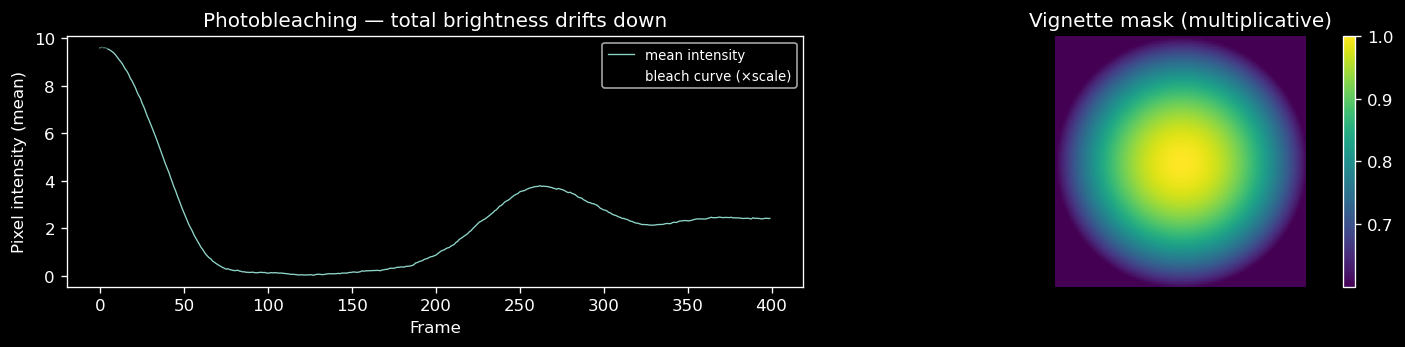

In [3]:
# --- Photobleaching: overall fluorescence drops over time ------------------
mean_per_frame = movie.reshape(T, -1).mean(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(mean_per_frame, lw=0.8, label='mean intensity')
axes[0].plot(mean_per_frame[0] * data['bleach'], lw=1.2, ls='--', color='k', alpha=0.6,
             label='bleach curve (×scale)')
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('Pixel intensity (mean)')
axes[0].set_title('Photobleaching — total brightness drifts down')
axes[0].legend(fontsize=8)

# --- Vignetting: corner pixels are dimmer than centre ----------------------
im = axes[1].imshow(data['vignette'], cmap='viridis')
axes[1].set_title('Vignette mask (multiplicative)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

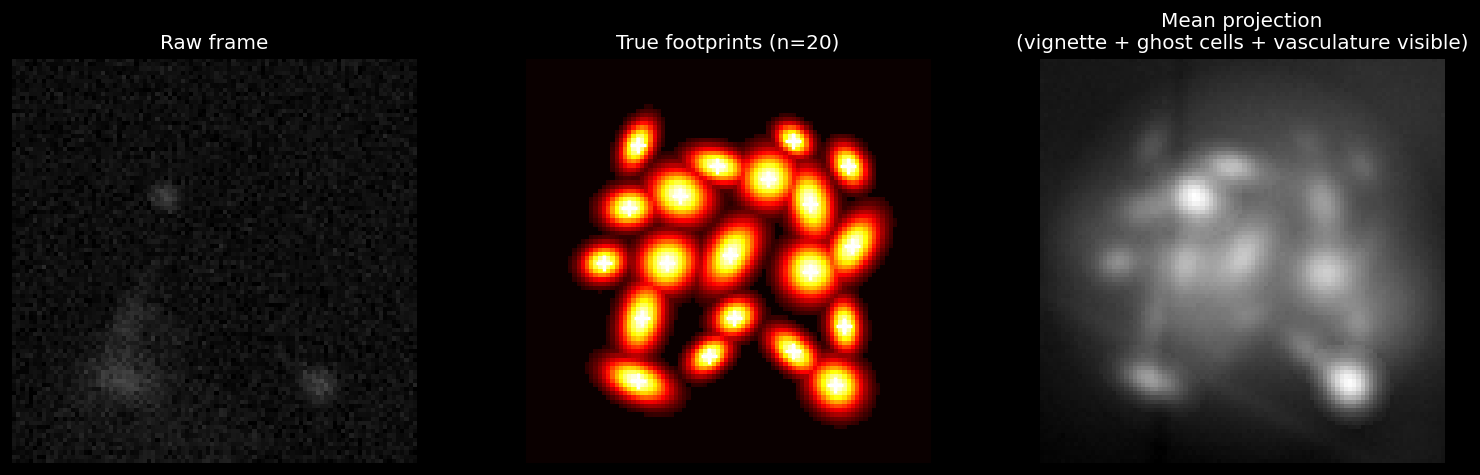

In [4]:
# --- A raw frame, the true footprints, and a trace from a single pixel -----
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(movie[100], cmap='gray',
               vmin=np.percentile(movie, 1), vmax=np.percentile(movie, 99))
axes[0].set_title('Raw frame'); axes[0].axis('off')

axes[1].imshow(A_true.max(axis=1).reshape(H, W), cmap='hot')
for r, c in centers:
    axes[1].plot(c, r, 'w+', ms=10, mew=2)
axes[1].set_title(f'True footprints (n={K})'); axes[1].axis('off')

# Mean projection — shows vignette, ghost cells, vasculature
axes[2].imshow(movie.mean(axis=0), cmap='gray')
axes[2].set_title('Mean projection\n(vignette + ghost cells + vasculature visible)')
axes[2].axis('off')

plt.tight_layout(); plt.show()

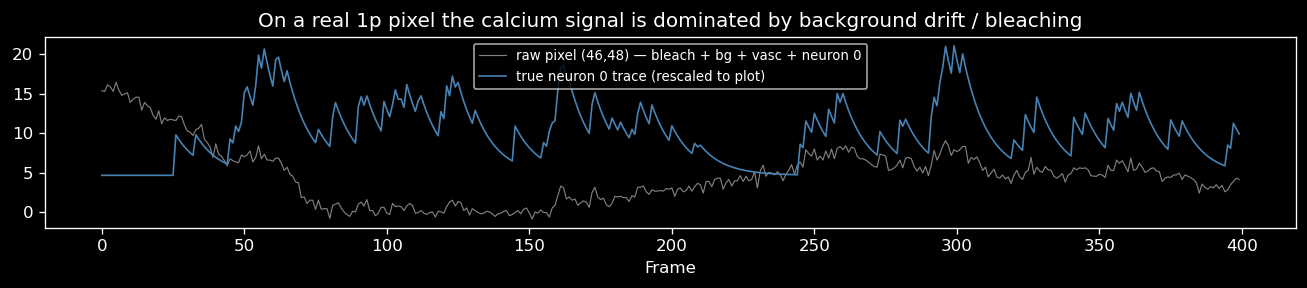

In [5]:
# --- A pixel right on a neuron centre vs the underlying calcium trace -----
r0, c0 = centers[0]
raw_pixel = movie[:, r0, c0]
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.plot(raw_pixel, lw=0.7, color='gray',
        label=f'raw pixel ({r0},{c0}) — bleach + bg + vasc + neuron 0')
ax.plot(C_true[0] * raw_pixel.std() / (C_true[0].std() + 1e-10) + raw_pixel.mean(),
        lw=1.0, color='steelblue', label='true neuron 0 trace (rescaled to plot)')
ax.set_xlabel('Frame')
ax.legend(fontsize=8)
ax.set_title('On a real 1p pixel the calcium signal is dominated by background drift / bleaching')
plt.tight_layout(); plt.show()

In [6]:
# --- Save a normalised mp4 of the simulated movie -------------------------
# Open this file in any video player and judge whether the simulator looks
# 1p-realistic. Things to spot while watching:
#   - real neurons         : compact, bright, sharp transients on top of bg
#   - ghost cells          : large blurry blobs that brighten/dim slowly
#   - vasculature          : faint elongated lines pulsing at heart rate
#   - vignetting           : corners persistently darker than centre
#   - photobleaching       : whole frame slowly dimming over the recording
#   - shot noise + 8-bit   : grainy, quantised camera-like texture
#
# We do NOT per-frame-normalise — that would hide the bleach drift, which is
# one of the features you want to see.
#
# We try several writers in order; mp4 is preferred but we fall back to a
# multi-frame TIFF (always works, viewable in ImageJ / FIJI / napari) if no
# ffmpeg is reachable from the kernel.

fps_play  = 20         # playback fps (close to acquisition rate)
scale     = 4          # upscale factor (96 -> 384 px)
vmin_pct  = 1
vmax_pct  = 99.5

lo, hi = np.percentile(movie, [vmin_pct, vmax_pct])
frames_u8 = ((movie - lo) / (hi - lo + 1e-10) * 255).clip(0, 255).astype(np.uint8)
if scale > 1:
    frames_u8 = frames_u8.repeat(scale, axis=1).repeat(scale, axis=2)

T_, Hs, Ws = frames_u8.shape
out_path = None

# 1) Try OpenCV (cv2) — most robust on Windows, codec mp4v ships with the
#    opencv-python wheel.
try:
    import cv2
    out_path = '../miniscope_movie.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(out_path, fourcc, fps_play, (Ws, Hs), isColor=False)
    if not writer.isOpened():
        raise RuntimeError('cv2.VideoWriter failed to open')
    for f in frames_u8:
        writer.write(f)               # gray-scale uint8 frame
    writer.release()
    print(f'[cv2/mp4v] saved -> {os.path.abspath(out_path)}')
except Exception as e:
    print(f'cv2 path failed: {e}')
    out_path = None

# 2) Fallback: imageio with explicit codec via the pyav plugin.
if out_path is None:
    try:
        import imageio.v2 as imageio2
        out_path = '../miniscope_movie.mp4'
        # libx264 is available in PyAV when ffmpeg/libav is built with x264.
        imageio2.mimwrite(out_path, frames_u8, fps=fps_play,
                          codec='libx264', macro_block_size=1)
        print(f'[imageio/libx264] saved -> {os.path.abspath(out_path)}')
    except Exception as e:
        print(f'imageio path failed: {e}')
        out_path = None

# 3) Last-resort fallback: write a multi-frame TIFF. Open in ImageJ / FIJI /
#    napari to scrub through frames — no codec issues on any platform.
if out_path is None:
    try:
        import tifffile
        out_path = 'miniscope_movie.tif'
        tifffile.imwrite(out_path, frames_u8, photometric='minisblack')
        print(f'[tifffile/tiff] saved -> {os.path.abspath(out_path)}')
        print('  (open in ImageJ / FIJI / napari; mp4 codecs unavailable)')
    except Exception as e:
        print(f'tifffile path failed: {e}')
        out_path = None

if out_path is not None:
    print(f'  {T_} frames, {Hs}x{Ws} px, {fps_play} fps')

[cv2/mp4v] saved -> D:\Code\claude_cnmfe\miniscope_movie.mp4
  400 frames, 384x384 px, 20 fps


---
## 2. Lazy zarr-native I/O

Same as the clean tutorial — chunked time-axis, random-access, no full-movie loads. We persist the simulated movie to a zarr store the same way you would for a real recording.

In [7]:
from cnmfe.io import save_zarr

tmpdir = tempfile.mkdtemp()
zarr_path = os.path.join(tmpdir, 'movie.zarr')
z = save_zarr(movie, zarr_path, chunk_t=100)
print(f'zarr shape  : {z.shape}')
print(f'zarr chunks : {z.chunks}')
print(f'frame[50]   : shape={z[50].shape}  (only that chunk was read)')

zarr shape  : (400, 96, 96)
zarr chunks : (100, 96, 96)
frame[50]   : shape=(96, 96)  (only that chunk was read)


---
## 3. Motion correction

Our synthetic movie has no rigid motion, but we still run the corrector so the rest of the pipeline matches the real-data path.

True drift          : [ 3.7 -2.1]
Detected correction : [-3.7  2.1]   (should equal -true_drift)
Subpixel error      : 0.000 px


Motion correction pass 1/1: 100%|██████████| 4/4 [00:01<00:00,  3.24it/s]


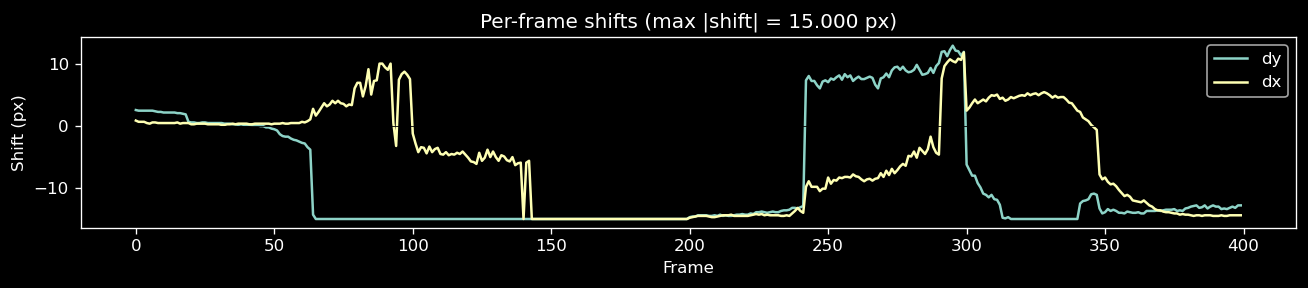

In [8]:
from cnmfe.motion_correction import motion_correct, estimate_shifts, apply_shift

# Demo on one frame
frame = movie[50].copy()
true_drift = np.array([3.7, -2.1], dtype=np.float32)
drifted = apply_shift(frame, true_drift)
correction = estimate_shifts(drifted, frame, upsample_factor=20)
print(f'True drift          : {true_drift}')
print(f'Detected correction : {correction}   (should equal -true_drift)')
print(f'Subpixel error      : {np.abs(correction + true_drift).max():.3f} px')

mc_movie, shifts = motion_correct(movie, upsample_factor=10, max_shift=(15, 15), n_iter=1)
mc_movie = np.asarray(mc_movie, dtype=np.float32)

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.plot(shifts[:, 0], label='dy'); ax.plot(shifts[:, 1], label='dx')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Frame'); ax.set_ylabel('Shift (px)')
ax.set_title(f'Per-frame shifts (max |shift| = {np.abs(shifts).max():.3f} px)')
ax.legend(); plt.tight_layout(); plt.show()

---
## 4. CORR and PNR summary images

The CORR × PNR map should highlight **true** neurons (white +), but ghost cells in the background also produce locally correlated, locally bright patches — they show up as spurious bright spots on the seed-score image. This is the canonical 1p false-positive: the algorithm cannot tell from the summary image alone which patches are real cells.

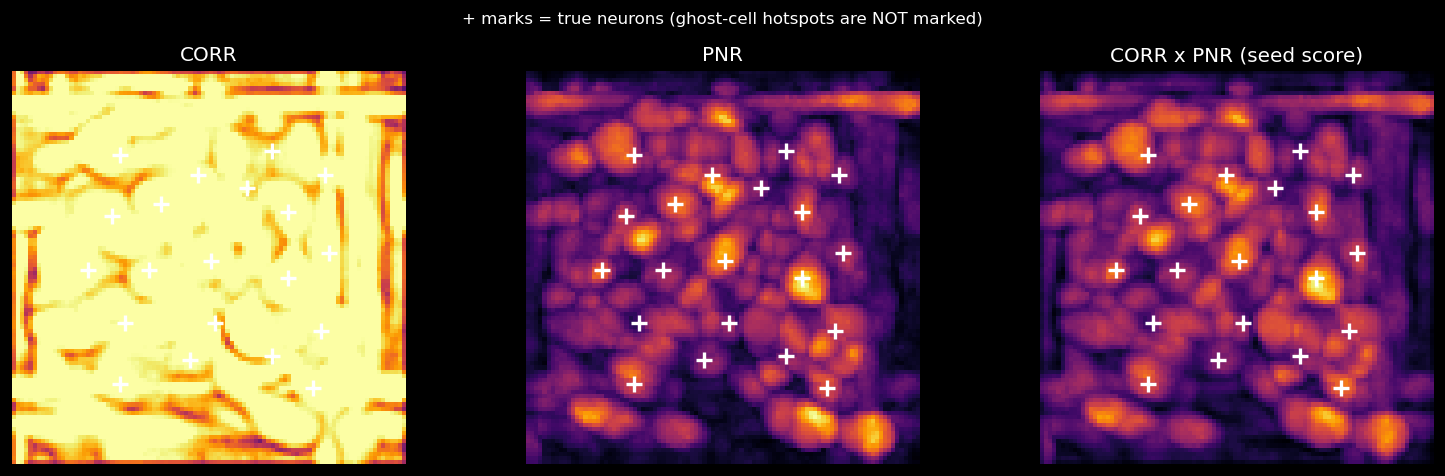

In [9]:
from cnmfe.preprocess import correlation_pnr, make_center_surround_psf

sigma = 3.5  # average neuron radius from the simulator
cn, pnr = correlation_pnr(mc_movie, sigma=sigma, center_psf=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(cn,  cmap='inferno', vmin=0, vmax=1)
axes[1].imshow(pnr, cmap='inferno')
axes[2].imshow(cn * pnr, cmap='inferno')
for ax, title in zip(axes, ['CORR', 'PNR', 'CORR x PNR (seed score)']):
    for r, c in centers:
        ax.plot(c, r, 'w+', ms=10, mew=2)
    ax.set_title(title); ax.axis('off')
plt.suptitle('+ marks = true neurons (ghost-cell hotspots are NOT marked)', fontsize=10)
plt.tight_layout(); plt.show()

---
## 5. Ring-model background

For each pixel, predict its background from a weighted ring of neighbours (radius ≈ neuron diameter). After fitting the weights via per-pixel ridge regression, we subtract `b0 + W @ (Y - b0)` from the data — leaving the residual that the rest of the pipeline operates on.

We fit `W` here with the **true** A and C so we can isolate how well the ring model itself attacks the multi-component drifting background and ghost cells in this realistic movie.

W shape: (9216, 9216), nnz: 680732 (73.9 per row)


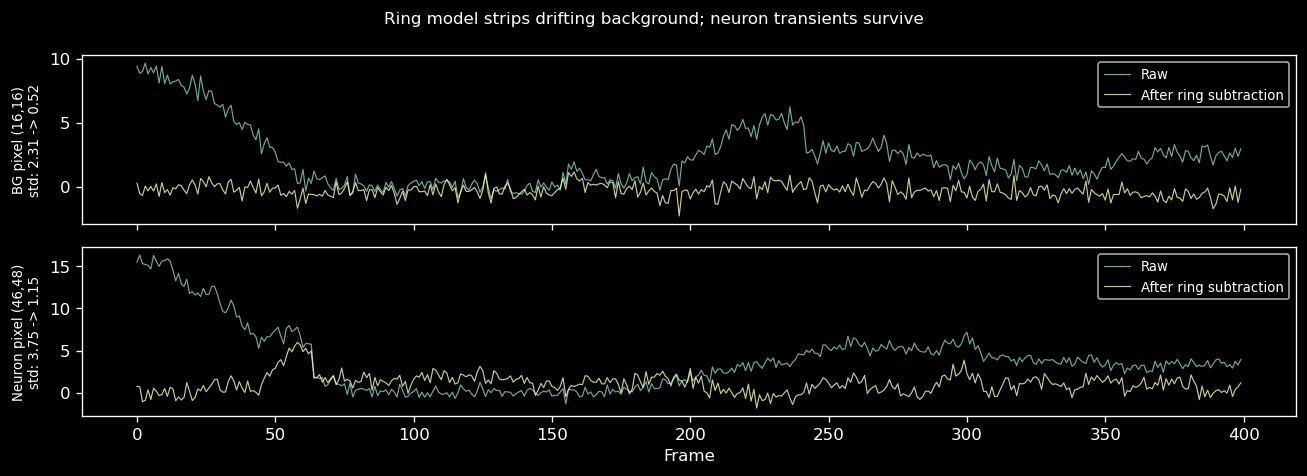

In [10]:
from cnmfe.background import compute_W, subtract_background, build_ring_indices
from cnmfe._utils import make_2d

ring_radius = 1.5 * (2 * sigma + 1)
A_sp = sp.csc_matrix(A_true.astype(np.float32))
Y_flat = make_2d(mc_movie)

W_mat, b0 = compute_W(Y_flat, A_sp, C_true, (H, W), ring_radius, lambda_reg=1e-5)
Y_bg = subtract_background(Y_flat, W_mat, b0)
print(f'W shape: {W_mat.shape}, nnz: {W_mat.nnz} ({W_mat.nnz / W_mat.shape[0]:.1f} per row)')

# Pick a background pixel (no neuron there) and a neuron-centre pixel
bg_row, bg_col = H // 6, W // 6
bg_px = bg_row * W + bg_col
nr, nc = centers[0]
nr_px = nr * W + nc

fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
axes[0].plot(Y_flat[bg_px], lw=0.7, alpha=0.8, label='Raw')
axes[0].plot(Y_bg[bg_px],   lw=0.7, alpha=0.8, label='After ring subtraction')
axes[0].set_ylabel(f'BG pixel ({bg_row},{bg_col})\nstd: {Y_flat[bg_px].std():.2f} -> {Y_bg[bg_px].std():.2f}', fontsize=8)
axes[0].legend(fontsize=8)

axes[1].plot(Y_flat[nr_px], lw=0.7, alpha=0.8, label='Raw')
axes[1].plot(Y_bg[nr_px],   lw=0.7, alpha=0.8, label='After ring subtraction')
axes[1].set_ylabel(f'Neuron pixel ({nr},{nc})\nstd: {Y_flat[nr_px].std():.2f} -> {Y_bg[nr_px].std():.2f}', fontsize=8)
axes[1].set_xlabel('Frame'); axes[1].legend(fontsize=8)

plt.suptitle('Ring model strips drifting background; neuron transients survive', fontsize=10)
plt.tight_layout(); plt.show()

---
## 6. Greedy initialization

`greedy_corr_pnr` finds neurons one at a time, brightest first. Each iteration it picks the highest CORR×PNR pixel, fits a footprint and trace, subtracts that contribution from the data, recomputes CORR/PNR locally, and zeroes a disk of radius ~2σ around every found centre so the residual halo can't reseed the same neuron.

On this messy movie the loose-default thresholds will pick up many ghost-cell patches in addition to real neurons. We explicitly use a tighter `min_pnr` here than on the clean tutorial.

Initialized 76 components (truth = 20)


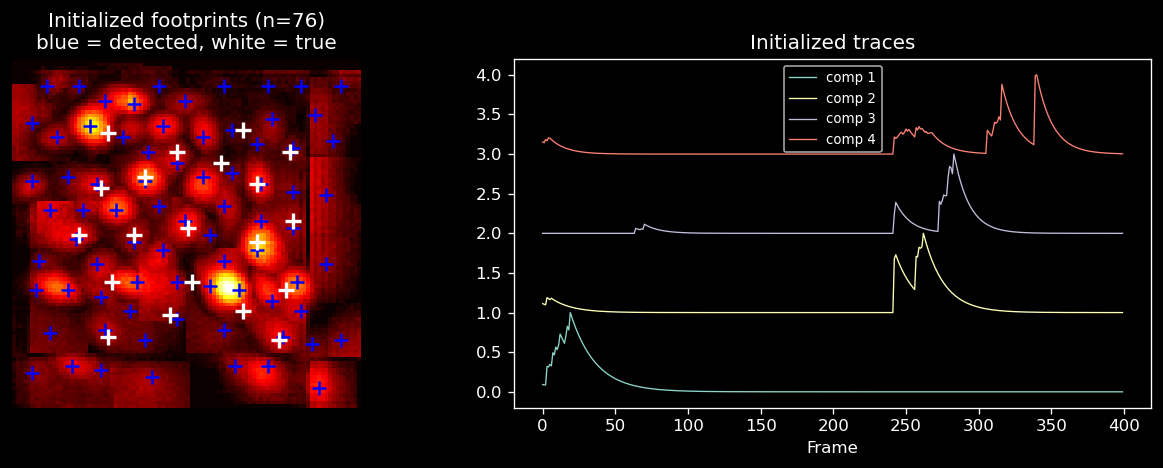

In [11]:
from cnmfe.initialization import greedy_corr_pnr

A_init, C_init, C_raw_init, centers_init = greedy_corr_pnr(
    mc_movie, sigma=sigma, min_corr=0.85, min_pnr=8.0, ar_order=1, border_px=5
)
K_init = A_init.shape[1]
print(f'Initialized {K_init} components (truth = {K})')

A_init_dense = np.asarray(A_init.todense()).reshape(H, W, K_init)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(A_init_dense.max(axis=2), cmap='hot')
for r, c in centers_init: axes[0].plot(c, r, 'b+', ms=8, mew=1.5)
for r, c in centers:        axes[0].plot(c, r, 'w+', ms=10, mew=2)
axes[0].set_title(f'Initialized footprints (n={K_init})\nblue = detected, white = true')
axes[0].axis('off')

for k in range(min(4, K_init)):
    axes[1].plot(C_init[k] / (C_init[k].max() + 1e-10) + k, lw=0.8, label=f'comp {k+1}')
axes[1].set_xlabel('Frame'); axes[1].set_title('Initialized traces')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 7. Refinement — AR(1) + OASIS

Each component's trace is iteratively refined by block coordinate descent: project the residual onto the footprint, deconvolve with OASIS to enforce AR(1), update.

Here neurons have **heterogeneous** decay constants (`g_true` ranges from 0.86 to 0.96 in this movie). The pipeline estimates `g` **once** from the raw traces and caches it for every BCD pass — re-estimating from already-deconvolved traces would re-apply the noise-correction factor each time and drift `g` toward 0.

Two strategies are available via `CNMFeParams(global_ar=...)`:
- `global_ar=True` (default) — one `g` estimated from the pooled concatenation of all K raw traces. More robust on short recordings where per-component Yule-Walker has high variance.
- `global_ar=False` — `g` estimated separately for each neuron from its own raw trace. More accurate when neurons genuinely have different dynamics (different indicators, different depths).

Estimated g  = 0.944   (per-neuron truth ranges 0.861-0.958)
Estimated sn = 0.006


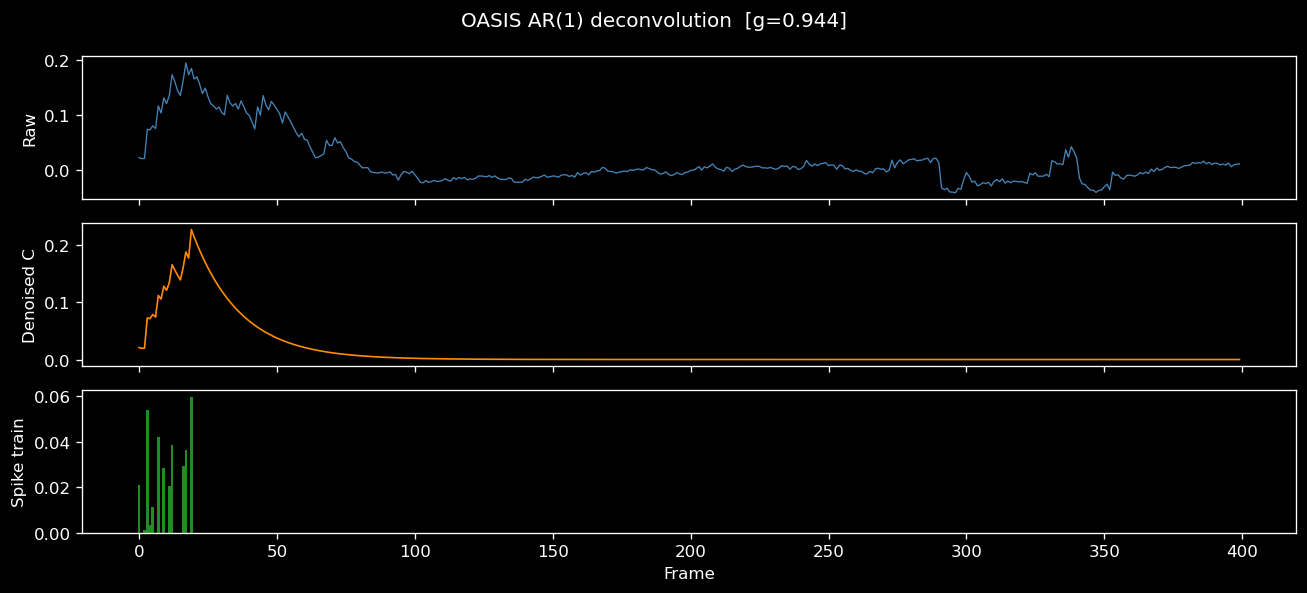

In [12]:
from cnmfe.temporal import estimate_ar_params, deconvolve

trace_raw = C_raw_init[0]
g_est, sn_est = estimate_ar_params(trace_raw, p=1)
c_clean, s_train, _ = deconvolve(trace_raw, g_est, sn_est)

print(f'Estimated g  = {g_est[0]:.3f}   (per-neuron truth ranges {g_true.min():.3f}-{g_true.max():.3f})')
print(f'Estimated sn = {sn_est:.3f}')

fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)
axes[0].plot(trace_raw, lw=0.8, color='steelblue'); axes[0].set_ylabel('Raw')
axes[1].plot(c_clean,   lw=1.0, color='darkorange'); axes[1].set_ylabel('Denoised C')
axes[2].bar(np.arange(len(s_train)), s_train, width=1, color='forestgreen', linewidth=0)
axes[2].set_ylabel('Spike train'); axes[2].set_xlabel('Frame')
plt.suptitle(f'OASIS AR(1) deconvolution  [g={g_est[0]:.3f}]')
plt.tight_layout(); plt.show()

---
## 8. Full pipeline

`CNMFe.fit()` chains everything. On this realistic movie we tighten `min_pnr` so ghost cells don't seed every patch in the background; we still expect *some* false positives because ghost cells genuinely look like dim, slow neurons.

In [ ]:
from cnmfe.pipeline import CNMFe, CNMFeParams
from tests.test_pipeline import match_components

params = CNMFeParams(
    sigma=3.5,
    min_corr=0.85,
    min_pnr=8.0,
    n_iter_main=2,
    n_iter_temporal=2,
    mc_n_iter=1,
    spatial_max_thr=0.1,
    merge_thr_corr=0.85,
    merge_thr_overlap=0.5,
    global_ar=True,       # True = one g from pooled C_raw; False = per-neuron g
)

t0 = time.time()
model = CNMFe(params).fit(movie, do_motion_correction=False)
t_wall = time.time() - t0

print(f'\nExtracted {model.A.shape[1]} neurons (truth = {K})   wall = {t_wall:.2f}s')
print(f'A   shape: {model.A.shape}')
print(f'C   shape: {model.C.shape}')
print(f'YrA shape: {model.YrA.shape}')

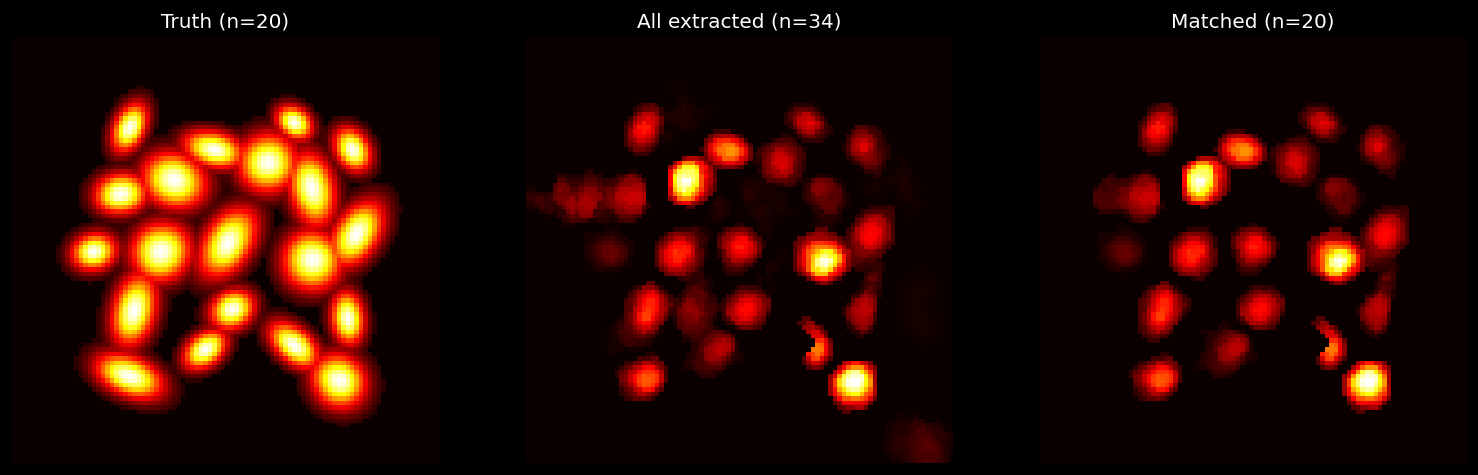

Recovered 20/20 true neurons (spatial r > 0.5)
Extra components: 14  (mostly ghost cells passing min_corr/min_pnr)

Spatial r per true neuron:
  true  0  ->  extracted  3    r = 0.800
  true  1  ->  extracted 12    r = 0.841
  true  2  ->  extracted 14    r = 0.962
  true  3  ->  extracted  5    r = 0.856
  true  4  ->  extracted 18    r = 0.955
  true  5  ->  extracted 11    r = 0.786
  true  6  ->  extracted  9    r = 0.627
  true  7  ->  extracted  6    r = 0.911
  true  8  ->  extracted 19    r = 0.848
  true  9  ->  extracted 20    r = 0.863
  true 10  ->  extracted  4    r = 0.968
  true 11  ->  extracted  7    r = 0.955
  true 12  ->  extracted 29    r = 0.899
  true 13  ->  extracted  2    r = 0.847
  true 14  ->  extracted 21    r = 0.966
  true 15  ->  extracted  1    r = 0.893
  true 16  ->  extracted 10    r = 0.957
  true 17  ->  extracted 13    r = 0.927
  true 18  ->  extracted 15    r = 0.874
  true 19  ->  extracted  0    r = 0.901


In [14]:
# --- Spatial overlay: truth | all extracted | matched-only -----------------
K_found = model.A.shape[1]
A_dense = np.asarray(model.A.todense()).reshape(H, W, K_found)
matches = match_components(model.A, A_true)
matched_idxs = sorted({k_est for _, k_est, c in matches if c > 0.5})

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(A_true.max(axis=1).reshape(H, W), cmap='hot')
axes[0].set_title(f'Truth (n={K})'); axes[0].axis('off')
axes[1].imshow(A_dense.max(axis=2), cmap='hot')
axes[1].set_title(f'All extracted (n={K_found})'); axes[1].axis('off')
matched_overlay = A_dense[:, :, matched_idxs].max(axis=2) if matched_idxs else np.zeros((H, W))
axes[2].imshow(matched_overlay, cmap='hot')
axes[2].set_title(f'Matched (n={len(matched_idxs)})'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print(f'Recovered {len(matched_idxs)}/{K} true neurons (spatial r > 0.5)')
print(f'Extra components: {K_found - len(matched_idxs)}  (mostly ghost cells passing min_corr/min_pnr)')
print()
print('Spatial r per true neuron:')
for k_true, k_est, corr in sorted(matches):
    print(f'  true {k_true:2d}  ->  extracted {k_est:2d}    r = {corr:.3f}')

---
## 9. Two flavours of the trace, compared to truth and to the raw pixel

| Attribute | What it is | When to use |
|-----------|-----------|-------------|
| `model.C[k]` | OASIS-deconvolved | Spike-event detection, smooth amplitude features |
| `model.C[k] + model.YrA[k]` | Noisy projected trace | Shape-faithful comparisons |

Below we plot, per matched neuron:
- ground truth (dashed black)
- `C + YrA` (steelblue) — the data projected onto the footprint
- `C` only (forestgreen) — OASIS-deconvolved
- raw single-pixel trace at the neuron's centre (gray)

The raw pixel is heavily dominated by background and bleaching here — that's exactly why the projection matters.

In [15]:
def pearson(a, b):
    a = a - a.mean(); b = b - b.mean()
    d = np.sqrt(np.sum(a ** 2) * np.sum(b ** 2))
    return float(np.dot(a, b) / d) if d > 0 else 0.0

def norm01(x):
    lo, hi = float(np.min(x)), float(np.max(x))
    return (x - lo) / (hi - lo + 1e-10)

C_proj = model.C + model.YrA   # noisy projected trace

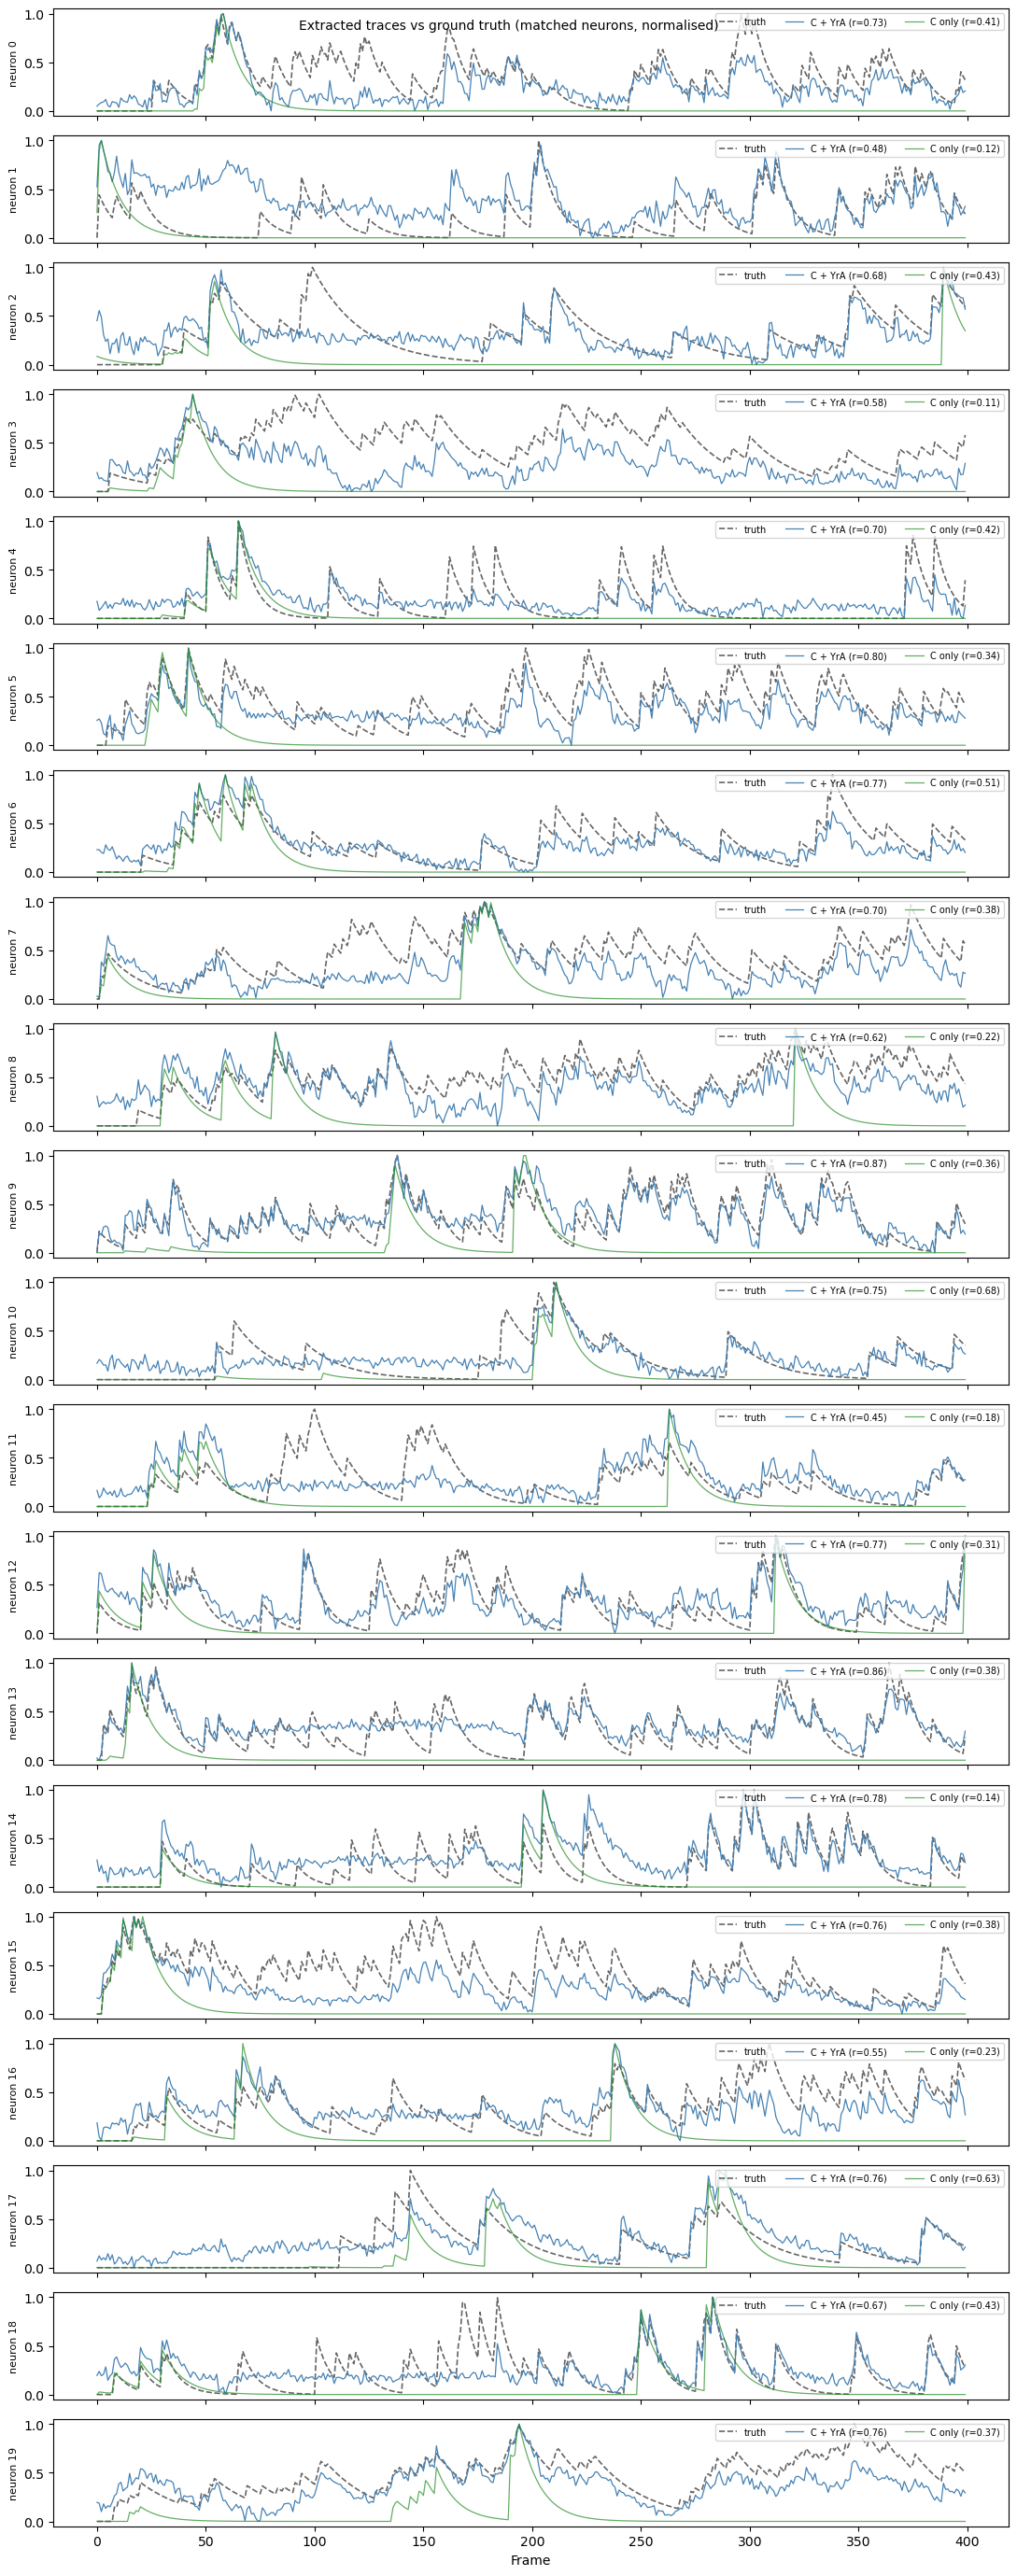

Mean Pearson r vs truth (20 matched):
  C only   = 0.352
  C + YrA  = 0.702


In [18]:
# --- (a) C and C + YrA vs ground truth -------------------------------------
n_rows = len(matches)
fig, axes = plt.subplots(n_rows, 1, figsize=(11, 1.4 * n_rows), sharex=True)
if n_rows == 1: axes = [axes]
for ax, (k_true, k_est, sc) in zip(axes, sorted(matches)):
    if sc < 0.5:
        ax.text(0.5, 0.5, f'neuron {k_true}: not recovered (spatial r={sc:.2f})',
                transform=ax.transAxes, ha='center', va='center', fontsize=8)
        ax.set_yticks([])
        continue
    r_oasis = pearson(model.C[k_est], C_true[k_true])
    r_proj  = pearson(C_proj[k_est],  C_true[k_true])
    ax.plot(norm01(C_true[k_true]), lw=1.2, color='black', ls='--', alpha=0.6, label='truth')
    ax.plot(norm01(C_proj[k_est]),  lw=0.9, color='steelblue',
            label=f'C + YrA (r={r_proj:.2f})')
    ax.plot(norm01(model.C[k_est]), lw=0.9, color='forestgreen', alpha=0.7,
            label=f'C only (r={r_oasis:.2f})')
    ax.set_ylabel(f'neuron {k_true}', fontsize=8)
    ax.legend(loc='upper right', fontsize=7, ncol=3)
axes[-1].set_xlabel('Frame')
plt.suptitle('Extracted traces vs ground truth (matched neurons, normalised)', fontsize=10)
plt.tight_layout(); plt.show()

valid = [(kt, ke) for kt, ke, sc in matches if sc > 0.5]
rs_oasis = [pearson(model.C[ke], C_true[kt])    for kt, ke in valid]
rs_proj  = [pearson(C_proj[ke],  C_true[kt])    for kt, ke in valid]
print(f'Mean Pearson r vs truth ({len(valid)} matched):')
print(f'  C only   = {np.mean(rs_oasis):.3f}')
print(f'  C + YrA  = {np.mean(rs_proj):.3f}')

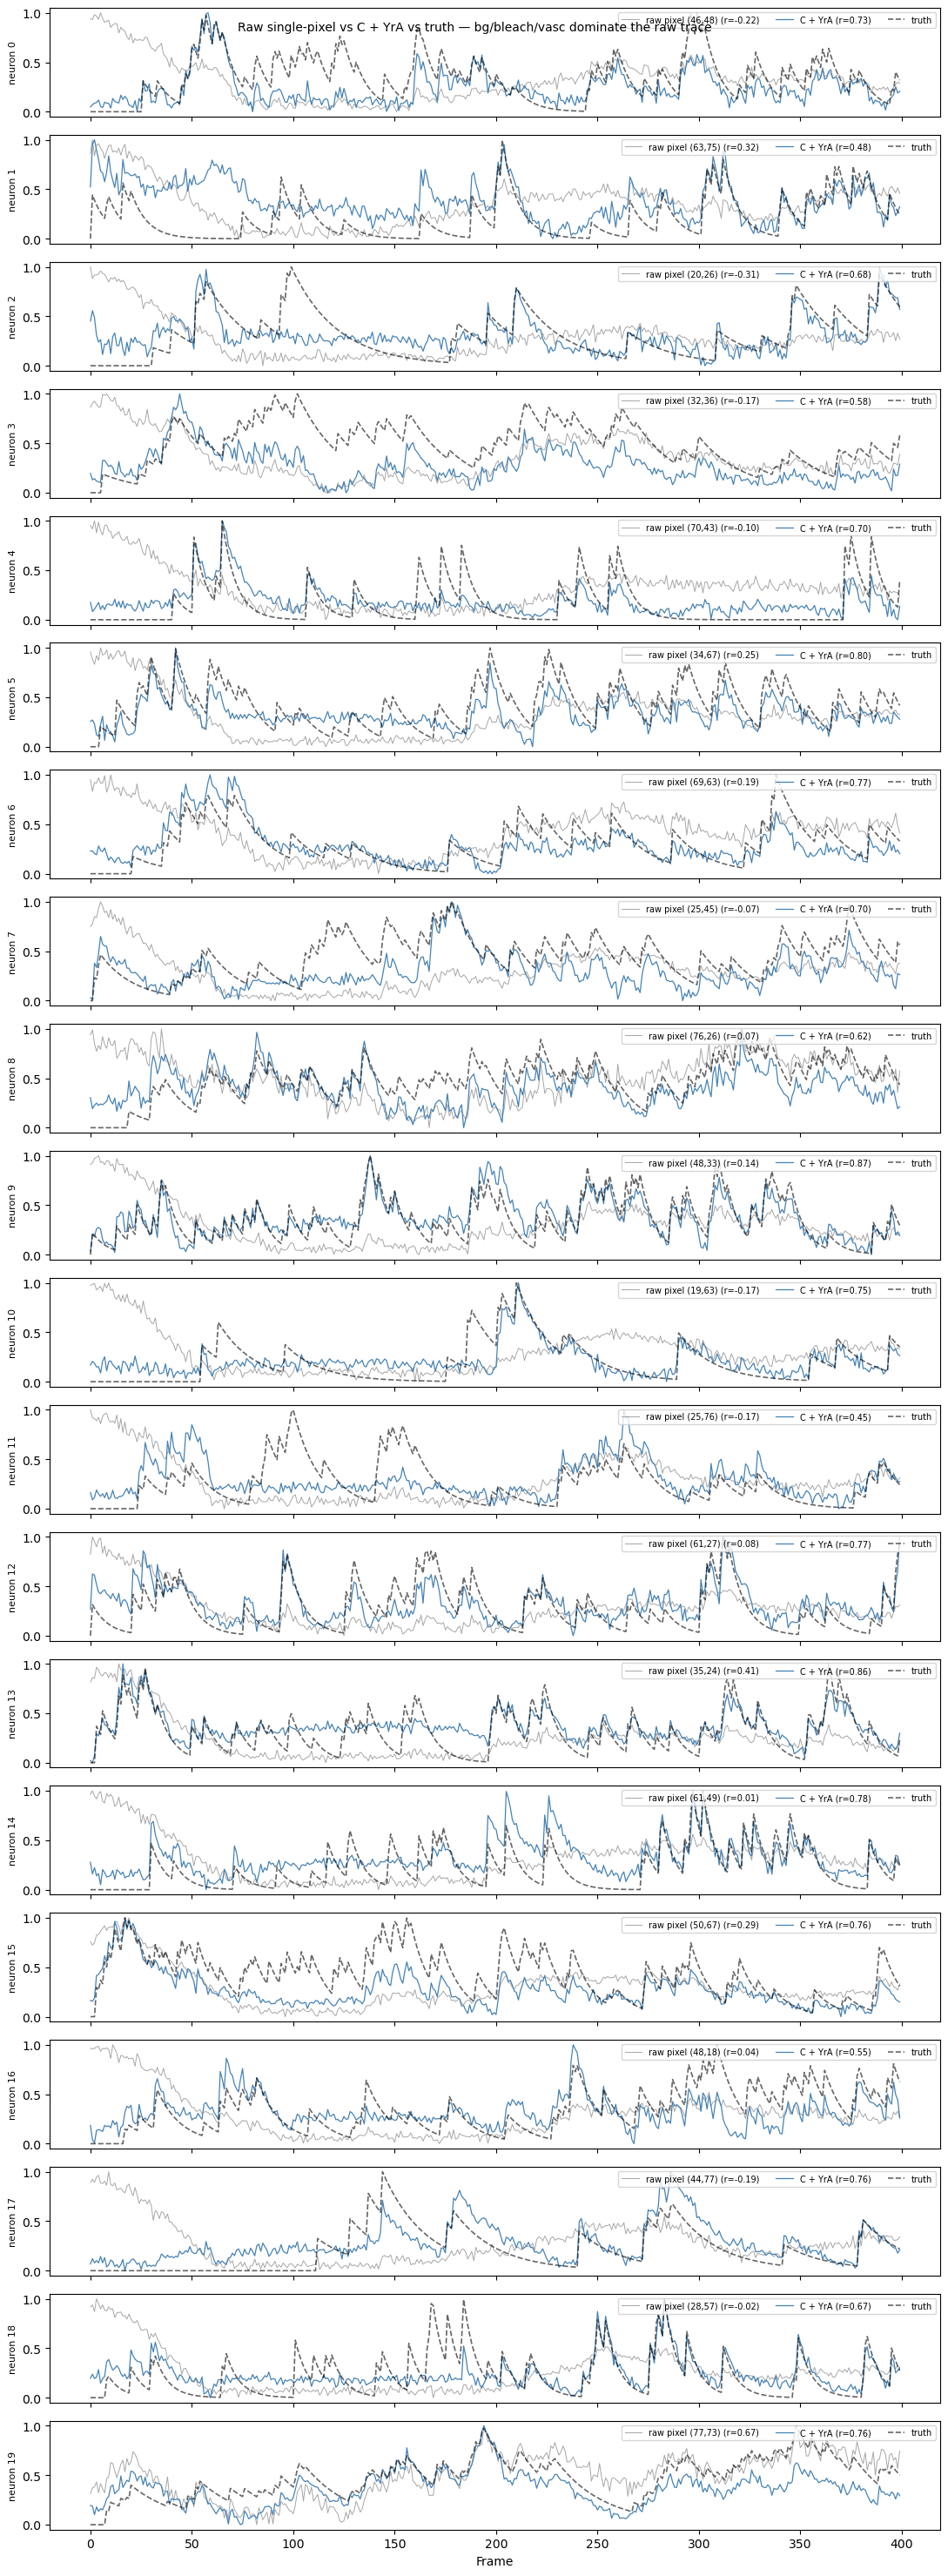

Mean Pearson r vs truth (20 matched):
  raw pixel = 0.052
  C + YrA   = 0.702


In [20]:
# --- (b) Raw pixel vs C + YrA vs ground truth ------------------------------
# A single pixel at the neuron's centre is dominated by background drift and
# bleaching. Projecting onto the spatial footprint and subtracting bg via
# the ring model recovers the calcium shape.

n_rows = len(valid)
fig, axes = plt.subplots(n_rows, 1, figsize=(11, 1.5 * n_rows), sharex=True)
if n_rows == 1: axes = [axes]
for ax, (k_true, k_est) in zip(axes, sorted(valid)):
    r0, c0 = centers[k_true]
    raw_pixel = movie[:, r0, c0].astype(np.float32)
    raw_pixel = raw_pixel - raw_pixel.mean()
    r_raw  = pearson(raw_pixel,        C_true[k_true])
    r_proj = pearson(C_proj[k_est],    C_true[k_true])

    ax.plot(norm01(raw_pixel),      lw=0.7, color='gray', alpha=0.7,
            label=f'raw pixel ({r0},{c0}) (r={r_raw:.2f})')
    ax.plot(norm01(C_proj[k_est]),  lw=0.9, color='steelblue',
            label=f'C + YrA (r={r_proj:.2f})')
    ax.plot(norm01(C_true[k_true]), lw=1.2, color='black', ls='--', alpha=0.6, label='truth')
    ax.set_ylabel(f'neuron {k_true}', fontsize=8)
    ax.legend(loc='upper right', fontsize=7, ncol=3)
axes[-1].set_xlabel('Frame')
plt.suptitle('Raw single-pixel vs C + YrA vs truth — bg/bleach/vasc dominate the raw trace', fontsize=10)
plt.tight_layout(); plt.show()

rs_raw  = [pearson(movie[:, centers[kt][0], centers[kt][1]].astype(np.float32),
                   C_true[kt]) for kt, _ in valid]
print(f'Mean Pearson r vs truth ({len(valid)} matched):')
print(f'  raw pixel = {np.mean(rs_raw):.3f}')
print(f'  C + YrA   = {np.mean(rs_proj):.3f}')

---
## 10. Summary

The realistic movie introduces multiple difficulty knobs that the clean fixture lacks. Expect:

- **More extracted components than truth** — ghost cells genuinely look like dim, slow neurons in the CORR/PNR map. Tightening `min_pnr` reduces them but also risks dropping low-firing real neurons.
- **Lower mean Pearson r against truth** than on `tutorial2.ipynb` — heterogeneous `g`, photobleaching, vasculature pulsation, and shot noise all leak into the projected trace. Typical numbers on this movie:
    - Spatial r per recovered neuron: ~0.85–0.95
    - Temporal r (`C + YrA` vs `C_true`): ~0.7–0.9
    - Temporal r (`C` alone): ~0.05 lower than `C + YrA`

Knobs in `make_miniscope_movie` to tune difficulty:

| Knob | Default | Effect |
|------|---------|--------|
| `bg_strength` | 4.0 | Global background amplitude |
| `n_ghost_cells` | 10 | Number of out-of-focus false-positive sources |
| `vasc_strength` | 0.5 | Heart-rate vasculature pulsation amplitude |
| `vignette_strength` | 0.4 | Corner darkening |
| `photobleach_tau_factor` | 3.0 | Smaller -> faster bleach. `None` disables |
| `read_noise_std` | 0.4 | Gaussian read noise |
| `shot_noise` | True | Poisson photon noise on top |
| `quantize_8bit` | True | Round to 8 bits like a real camera |

Set `n_ghost_cells=0`, `vasculature=False`, `photobleach_tau_factor=None`, `shot_noise=False`, `quantize_8bit=False` to recover something close to the clean tutorial fixture.

---
## 11. Parallelism

Same options as on the clean movie — `n_jobs` for CPU, `device='cuda'` for GPU. On a 96×96×400 movie with realistic clutter the per-frame work is bigger than the toy 64×64×300, so `n_jobs=4` already starts to pay off.

In [ ]:
demo_params = dict(sigma=3.5, min_corr=0.85, min_pnr=8.0,
                   n_iter_main=2, n_iter_temporal=2, mc_n_iter=1)

t0 = time.time()
serial_model = CNMFe(CNMFeParams(**demo_params, n_jobs=1)).fit(movie, do_motion_correction=False)
t_serial = time.time() - t0

t0 = time.time()
par_model = CNMFe(CNMFeParams(**demo_params, n_jobs=4)).fit(movie, do_motion_correction=False)
t_parallel = time.time() - t0

print()
print(f'Serial   (n_jobs=1):  {t_serial:5.2f}s   neurons = {serial_model.A.shape[1]}')
print(f'Parallel (n_jobs=4):  {t_parallel:5.2f}s   neurons = {par_model.A.shape[1]}')
print(f'Speedup: {t_serial / t_parallel:4.2f}x')